In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

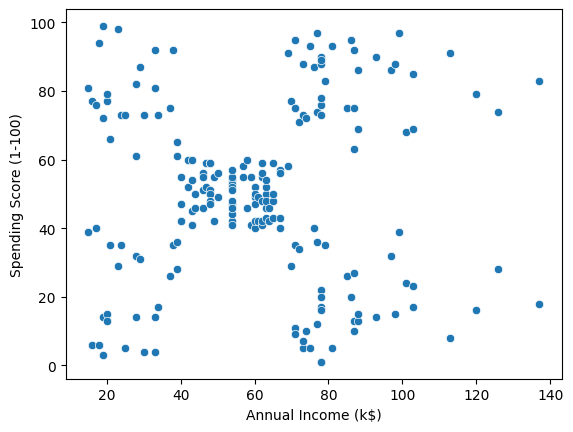

In [30]:
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"])

<Axes: xlabel='Gender', ylabel='Spending Score (1-100)'>

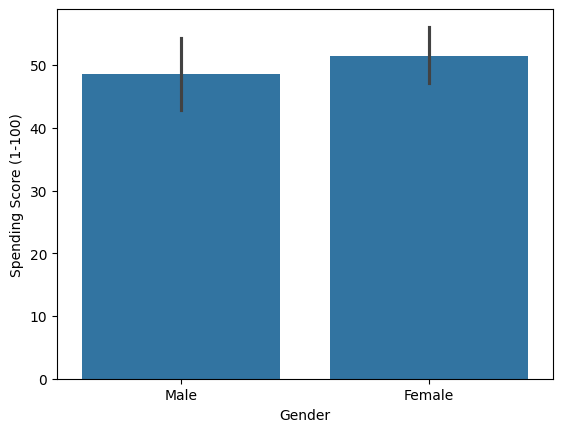

In [11]:
sns.barplot(x=df["Gender"], y=df["Spending Score (1-100)"])

In [14]:
x = df.iloc[:, 3:]

In [15]:
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [16]:
from sklearn.cluster import KMeans

In [19]:
wcss = []
for i in range(1,16):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

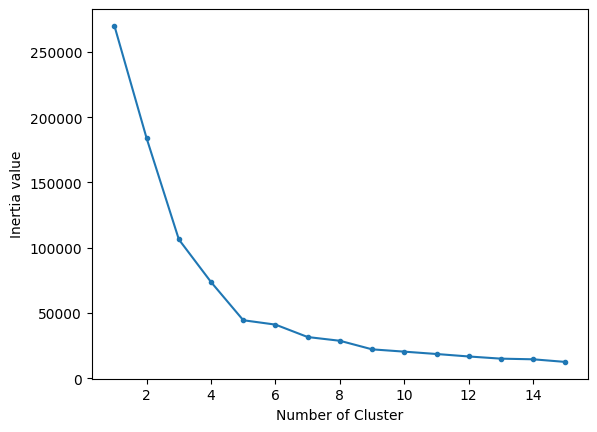

In [24]:
plt.plot(range(1,16), wcss, marker=".")
plt.xlabel("Number of Cluster")
plt.ylabel("Inertia value")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(x)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [27]:
labels = kmeans.labels_
labels

array([4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 2,
       4, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 3, 0, 2, 0, 3, 0, 3, 0,
       2, 0, 3, 0, 3, 0, 3, 0, 3, 0, 2, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0], dtype=int32)

In [28]:
df["Labels"] = labels

In [29]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Labels
0,1,Male,19,15,39,4
1,2,Male,21,15,81,1
2,3,Female,20,16,6,4
3,4,Female,23,16,77,1
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,3
197,198,Male,32,126,74,0
198,199,Male,32,137,18,3


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

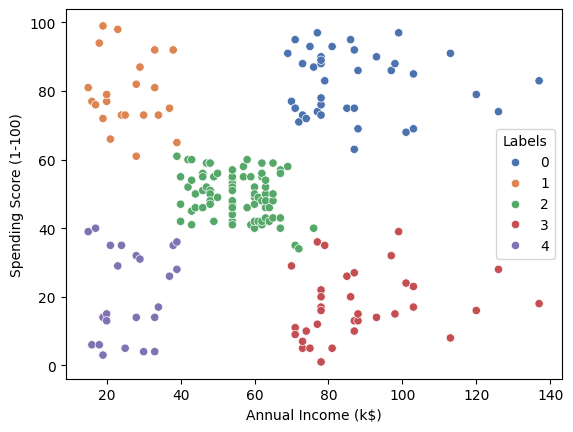

In [32]:
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], hue=df["Labels"], palette="deep")

In [35]:
df.drop(columns=["CustomerID"], axis=1, inplace=True)

In [36]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Labels
0,Male,19,15,39,4
1,Male,21,15,81,1
2,Female,20,16,6,4
3,Female,23,16,77,1
4,Female,31,17,40,4
...,...,...,...,...,...
195,Female,35,120,79,0
196,Female,45,126,28,3
197,Male,32,126,74,0
198,Male,32,137,18,3


In [37]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [38]:
from sklearn.preprocessing import LabelEncoder

In [39]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [40]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Labels
0,1,19,15,39,4
1,1,21,15,81,1
2,0,20,16,6,4
3,0,23,16,77,1
4,0,31,17,40,4
...,...,...,...,...,...
195,0,35,120,79,0
196,0,45,126,28,3
197,1,32,126,74,0
198,1,32,137,18,3


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [42]:
X = df.drop("Labels", axis=1)
y = df["Labels"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [45]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
y_pred = model.predict(X_test)

In [50]:
y_train_pred = model.predict(X_train)

In [47]:
y_pred

array([2, 1, 4, 3, 3, 2, 2, 3, 3, 1, 2, 3, 0, 2, 3, 0, 2, 3, 2, 2, 2, 4,
       3, 2, 2, 2, 2, 2, 0, 2, 1, 4, 2, 2, 3, 2, 0, 0, 3, 2], dtype=int32)

In [51]:
print("Train Accuracy : ", accuracy_score(y_train, y_train_pred))
print("Test Accuracy : ", accuracy_score(y_test, y_pred))

Train Accuracy :  1.0
Test Accuracy :  0.975


In [60]:
def prediction(gender, age, annual_income, spending_score):
    input_df = pd.DataFrame({
        "Gender":[gender],
        "Age":[age],
        "Annual Income (k$)":[annual_income],
        "Spending Score (1-100)":[spending_score]
    })

    input_df["Gender"] = le.transform(input_df["Gender"])

    prediction = model.predict(input_df)[0]
    print("Cluster No.", prediction)
    if prediction == 0:
        print("High Annual income and High Spending score")
    elif prediction == 1:
        print("Low Annual income and High Spending score")
    elif prediction == 2:
        print("Average Annual income and Average Spending score")
    elif prediction == 3:
        print("High Annual income and Low Spending score")
    elif prediction == 4:
        print("Low Annual income and Low Spending score")

In [62]:
prediction("Male", 19, 50, 70)

Cluster No. 1
Low Annual income and High Spending score


In [63]:
prediction("Female", 22, 80, 50)

Cluster No. 2
Average Annual income and Average Spending score


In [64]:
prediction("Female", 45, 134, 90)

Cluster No. 0
High Annual income and High Spending score


In [66]:
prediction("Male", 28, 65, 30)

Cluster No. 2
Average Annual income and Average Spending score
